# COMP4531 Deep Learning Final Project
## Improving Middle-Rating Classification in Yelp Reviews using LSTM Networks

**Author:** Ben Funk  
**Date:** March 2026  
**Dataset:** Yelp Open Dataset (2005-2022)

---
## 1. Problem Statement

### 1.1 The Problem

Star rating prediction from review text is a fundamental NLP task with significant business applications. However, **models consistently struggle to classify middle ratings (2, 3, and 4 stars) compared to extreme ratings (1 and 5 stars)**. This phenomenon occurs because:

- **1-star reviews** contain strongly negative language ("terrible", "worst", "never again")
- **5-star reviews** contain strongly positive language ("amazing", "best", "highly recommend")
- **2-4 star reviews** contain mixed sentiments, qualifiers, and ambiguous language ("good but...", "could be better", "decent")

### 1.2 Why Deep Learning?

Deep learning, specifically **LSTM (Long Short-Term Memory) networks**, is well-suited for this problem because:

1. **Sequential Context**: LSTMs can capture long-range dependencies in text, understanding how sentiment evolves throughout a review
2. **Memory Mechanism**: The gating mechanisms help distinguish subtle differences between middle ratings
3. **Bidirectional Processing**: Bi-LSTMs can read context from both directions, capturing nuanced expressions like "not bad" or "could be worse"
4. **Large Dataset**: With ~7 million Yelp reviews, we have sufficient data to train deep neural networks effectively

### 1.3 Research Question

**Can LSTM networks improve classification accuracy for middle ratings (2-4 stars) on Yelp reviews, and does bidirectional processing provide additional benefit over unidirectional LSTMs?**

---
## 2. Problem Setup

### 2.1 Input/Output Specification

| Variable | Type | Range/Encoding | Description |
|----------|------|----------------|-------------|
| **Input: Review Text** | Sequence of integers | [0, vocab_size-1] | Tokenized text converted to integer indices via vocabulary mapping |
| **Input: Sequence Length** | Integer | Fixed at 200 tokens | Padded/truncated to uniform length |
| **Input: Padding Mask** | Binary | 0 (padding) or 1 (real token) | Implicit in model (PAD token = 0) |
| **Output: Star Rating** | Integer class | 0-4 (represents 1-5 stars) | 5-class classification (0=1-star, 4=5-star) |
| **Embedding Dimension** | Integer | 100 | Dense vector representation of each word |
| **LSTM Hidden Dimension** | Integer | 128 | Size of LSTM hidden state |

### 2.2 Data Processing Pipeline

```
Raw JSON → Load Reviews → Balance Classes → Train/Val/Test Split → Tokenization → Vocabulary Building → Integer Encoding → Padding → PyTorch Tensors
```

---
## 3. Data Exploration & Problem Analysis

### 3.1 Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")

Libraries imported successfully
PyTorch version: 2.7.1


In [2]:
# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [22]:
# Load raw Yelp review data from JSON
print("Loading Yelp review dataset from JSON...")
print("This may take a few minutes due to the large file size (5GB)\n")

reviews = []

# Count reviews per star rating
star_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
samples_per_star = 500000

with open('Data/Raw/yelp_academic_dataset_review.json', 'r', encoding='utf-8') as f:
	for i, line in enumerate(f):
		review = json.loads(line)
		stars = review['stars']

		# Only add if we haven't reached 500k for this star rating
		if star_counts[stars] < samples_per_star:
			reviews.append({
				'text': review['text'],
				'stars': stars
			})
			star_counts[stars] += 1

		# Check if we have 500k for each star
		if all(count >= samples_per_star for count in star_counts.values()):
			break

		if (i + 1) % 100000 == 0:
			print(f"  Loaded {i + 1:,} reviews...")

print(f"\nTotal reviews loaded: {len(reviews):,}")
print("\nReviews per star rating:")
for star in range(1, 6):
	print(f"  {star} stars: {star_counts[star]:,}")

# Create DataFrame
df = pd.DataFrame(reviews)
print(f"DataFrame created with {len(df):,} rows")


Loading Yelp review dataset from JSON...
This may take a few minutes due to the large file size (5GB)

  Loaded 100,000 reviews...
  Loaded 200,000 reviews...
  Loaded 300,000 reviews...
  Loaded 400,000 reviews...
  Loaded 500,000 reviews...
  Loaded 600,000 reviews...
  Loaded 700,000 reviews...
  Loaded 800,000 reviews...
  Loaded 900,000 reviews...
  Loaded 1,000,000 reviews...
  Loaded 1,100,000 reviews...
  Loaded 1,200,000 reviews...
  Loaded 1,300,000 reviews...
  Loaded 1,400,000 reviews...
  Loaded 1,500,000 reviews...
  Loaded 1,600,000 reviews...
  Loaded 1,700,000 reviews...
  Loaded 1,800,000 reviews...
  Loaded 1,900,000 reviews...
  Loaded 2,000,000 reviews...
  Loaded 2,100,000 reviews...
  Loaded 2,200,000 reviews...
  Loaded 2,300,000 reviews...
  Loaded 2,400,000 reviews...
  Loaded 2,500,000 reviews...
  Loaded 2,600,000 reviews...
  Loaded 2,700,000 reviews...
  Loaded 2,800,000 reviews...
  Loaded 2,900,000 reviews...
  Loaded 3,000,000 reviews...
  Loaded 3,100,

### 3.2 Data Distribution Analysis


Original Star Rating Distribution:
  1 stars:  500,000 (20.00%)
  2 stars:  500,000 (20.00%)
  3 stars:  500,000 (20.00%)
  4 stars:  500,000 (20.00%)
  5 stars:  500,000 (20.00%)


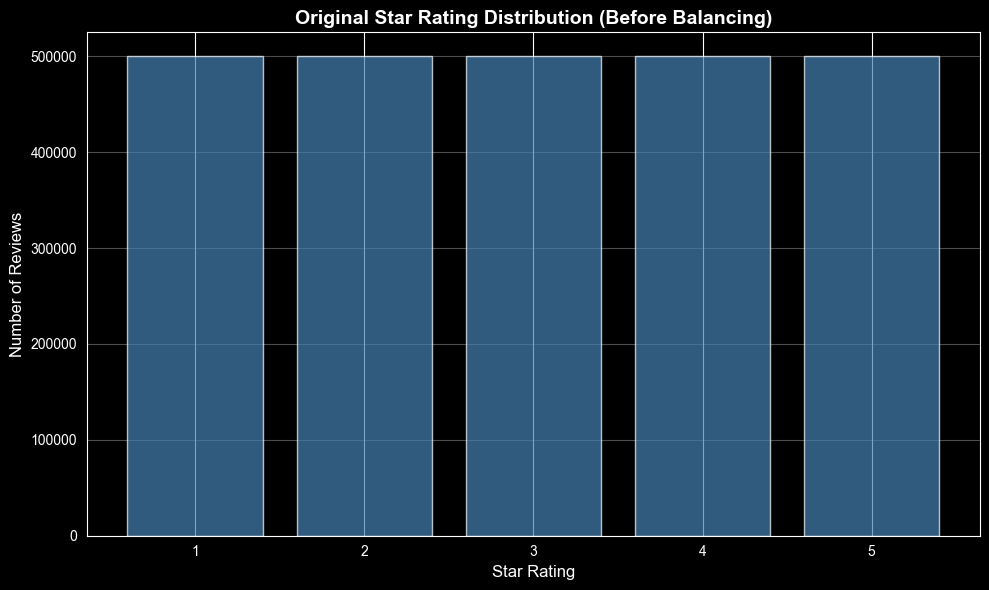


INSIGHT: Yelp reviews are heavily skewed toward positive ratings (4-5 stars).
This is typical for review platforms - satisfied customers are more likely to review.


In [23]:
# Analyze class distribution BEFORE balancing
print("\nOriginal Star Rating Distribution:")
print("="*50)
star_counts = df['stars'].value_counts().sort_index()
for star in range(1, 6):
    count = star_counts.get(star, 0)
    pct = (count / len(df)) * 100
    print(f"  {star} stars: {count:>8,} ({pct:>5.2f}%)")

# Visualize original distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.bar(star_counts.index, star_counts.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Original Star Rating Distribution (Before Balancing)', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 6))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: Yelp reviews are heavily skewed toward positive ratings (4-5 stars).")
print("This is typical for review platforms - satisfied customers are more likely to review.")

### 3.3 Data Cleaning and Balancing

**Why balance the data?**
- Original distribution is skewed toward positive reviews
- Without balancing, model would simply predict 4-5 stars for everything
- Balancing ensures model learns to distinguish all 5 classes equally

In [24]:
# Balance dataset - take equal samples from each star rating
print("\nBalancing dataset across star ratings...")
min_count = df['stars'].value_counts().min()
samples_per_class = min(min_count, 50000)  # 50k per class max

balanced_dfs = []
for star in range(1, 6):
    subset = df[df['stars'] == star].sample(n=samples_per_class, random_state=RANDOM_SEED)
    balanced_dfs.append(subset)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)  # Shuffle

print(f"Balanced dataset size: {len(df_balanced):,} reviews")
print(f"Reviews per star rating: {samples_per_class:,}")

# Verify balance
print("\nBalanced Distribution:")
balanced_counts = df_balanced['stars'].value_counts().sort_index()
for star in range(1, 6):
    count = balanced_counts.get(star, 0)
    pct = (count / len(df_balanced)) * 100
    print(f"  {star} stars: {count:>8,} ({pct:>5.2f}%)")


Balancing dataset across star ratings...
Balanced dataset size: 250,000 reviews
Reviews per star rating: 50,000

Balanced Distribution:
  1 stars:   50,000 (20.00%)
  2 stars:   50,000 (20.00%)
  3 stars:   50,000 (20.00%)
  4 stars:   50,000 (20.00%)
  5 stars:   50,000 (20.00%)


### 3.4 Train/Val/Test Split

In [25]:
# Split into train, val, test: 70% / 15% / 15%
train_df, temp_df = train_test_split(df_balanced, test_size=0.30, random_state=RANDOM_SEED, stratify=df_balanced['stars'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_SEED, stratify=temp_df['stars'])

print("\nData split:")
print(f"  Train: {len(train_df):,} samples ({len(train_df)/len(df_balanced)*100:.1f}%)")
print(f"  Validation: {len(val_df):,} samples ({len(val_df)/len(df_balanced)*100:.1f}%)")
print(f"  Test: {len(test_df):,} samples ({len(test_df)/len(df_balanced)*100:.1f}%)")

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


Data split:
  Train: 175,000 samples (70.0%)
  Validation: 37,500 samples (15.0%)
  Test: 37,500 samples (15.0%)


### 3.5 Text Analysis


Review Length Statistics:
  Mean: 116.7 words
  Median: 85.0 words
  Std: 106.0 words
  Min: 1 words
  Max: 1010 words
  95th percentile: 318.0 words


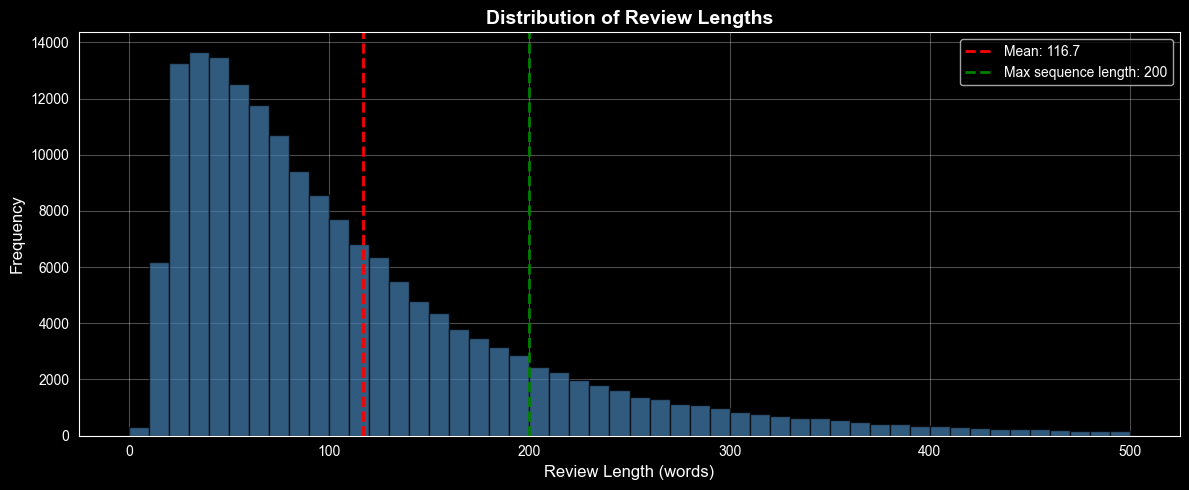


INSIGHT: Choosing max_length=200 captures most reviews without excessive truncation.


In [26]:
# Analyze review lengths
train_df['text_length'] = train_df['text'].str.split().str.len()

print("\nReview Length Statistics:")
print("="*50)
print(f"  Mean: {train_df['text_length'].mean():.1f} words")
print(f"  Median: {train_df['text_length'].median():.1f} words")
print(f"  Std: {train_df['text_length'].std():.1f} words")
print(f"  Min: {train_df['text_length'].min()} words")
print(f"  Max: {train_df['text_length'].max()} words")
print(f"  95th percentile: {train_df['text_length'].quantile(0.95):.1f} words")

# Visualize
plt.figure(figsize=(12, 5))
plt.hist(train_df['text_length'], bins=50, range=(0, 500), color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(train_df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_df["text_length"].mean():.1f}')
plt.axvline(200, color='green', linestyle='--', linewidth=2, label='Max sequence length: 200')
plt.xlabel('Review Length (words)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Review Lengths', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: Choosing max_length=200 captures most reviews without excessive truncation.")

### 3.6 Sample Reviews by Rating

In [27]:
# Show sample reviews
print("\n" + "="*80)
print("SAMPLE REVIEWS BY STAR RATING")
print("="*80)

for star in [1, 2, 3, 4, 5]:
    sample = train_df[train_df['stars'] == star]['text'].iloc[0]
    print(f"\n{star} STAR REVIEW:")
    print("-" * 80)
    print(sample[:250] + "..." if len(sample) > 250 else sample)


SAMPLE REVIEWS BY STAR RATING

1 STAR REVIEW:
--------------------------------------------------------------------------------
The girls at the front suck at their job especially the one with purple hair...the worst service. They also don't wear masks at all.

2 STAR REVIEW:
--------------------------------------------------------------------------------
Lacking a lot! Still on the look out for good BBQ in Tampa!.

3 STAR REVIEW:
--------------------------------------------------------------------------------
Poutine is probably one of my favourite things in Canada. The hype about La Poutine was quite big but to be honest, i enjoyed the poutine from It'dog much more. It'dog is right across the street and is much more reasonable. But again, this is a perso...

4 STAR REVIEW:
--------------------------------------------------------------------------------
Northdale Cleaners has new owners now and I'm very pleased with their service.  I go through a lot of dress shirts and their prices a

### 3.7 Baseline Model

Before building LSTMs, establish baseline performance:

In [28]:
# Baseline expectations
print("\nBASELINE PERFORMANCE:")
print("="*50)
print(f"Random guessing: {1/5:.2%} (20%)")
print(f"Majority class (balanced): {1/5:.2%} (20%)")
print("\nExpected LSTM performance: 55-65%")
print("State-of-the-art (BERT): 65-70%")


BASELINE PERFORMANCE:
Random guessing: 20.00% (20%)
Majority class (balanced): 20.00% (20%)

Expected LSTM performance: 55-65%
State-of-the-art (BERT): 65-70%


---
## 4. Neural Network Implementation

### 4.1 Text Preprocessing

In [29]:
# Tokenize and build vocabulary
print("\nTokenizing reviews...")

def simple_tokenize(text):
    """Simple whitespace tokenization, lowercase."""
    return text.lower().split()

# Tokenize training set
train_tokens = train_df['text'].apply(simple_tokenize)

# Build vocabulary from training set only
print("Building vocabulary...")
all_words = []
for tokens in train_tokens:
    all_words.extend(tokens)

word_counts = Counter(all_words)
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in word_counts.most_common():
    if word not in vocab:
        vocab[word] = len(vocab)

vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size:,} unique tokens")
print(f"Total words in training: {len(all_words):,}")


Tokenizing reviews...
Building vocabulary...
Vocabulary size: 338,036 unique tokens
Total words in training: 20,427,591


In [30]:
# Convert text to sequences
MAX_LENGTH = 200

def text_to_sequence(text, vocab, max_length=200):
    """Convert text to padded sequence of integers."""
    tokens = simple_tokenize(text)
    sequence = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # Truncate or pad
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    else:
        sequence = sequence + [vocab['<PAD>']] * (max_length - len(sequence))
    
    return sequence

print("\nConverting text to sequences...")
X_train = np.array([text_to_sequence(text, vocab, MAX_LENGTH) for text in train_df['text']])
X_val = np.array([text_to_sequence(text, vocab, MAX_LENGTH) for text in val_df['text']])
X_test = np.array([text_to_sequence(text, vocab, MAX_LENGTH) for text in test_df['text']])

# Convert labels to 0-indexed (0=1star, 4=5star)
y_train = train_df['stars'].values - 1
y_val = val_df['stars'].values - 1
y_test = test_df['stars'].values - 1

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Labels range: {y_train.min()} to {y_train.max()}")


Converting text to sequences...
X_train shape: (175000, 200)
X_val shape: (37500, 200)
X_test shape: (37500, 200)
Labels range: 0.0 to 4.0


### 4.2 Create PyTorch DataLoaders

In [31]:
# Convert to PyTorch tensors
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create dataloaders
BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"\nDataLoaders created with batch_size={BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


DataLoaders created with batch_size=512
  Train batches: 342
  Val batches: 74
  Test batches: 74


### 4.3 Model Architectures

In [ ]:
class UnidirectionalLSTM(nn.Module):
    """Unidirectional (forward-only) LSTM for text classification."""
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.5):
        super(UnidirectionalLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)  # Note: hidden_dim, not hidden_dim*2
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden = hidden.squeeze(0)  # Remove the num_layers dimension
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

class BidirectionalLSTM(nn.Module):
    """Bidirectional LSTM for text classification."""
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.5):
        super(BidirectionalLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 for bidirectional
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden = self.dropout(hidden)
        output = self.fc(hidden)
        return output

print("Unidirectional LSTM model defined")
print("Bidirectional LSTM model defined")

### 4.4 Training Functions

In [33]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(dataloader), correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(dataloader), correct / total

def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

print("Training functions defined")

Training functions defined


### 4.5 Train Model

In [ ]:
# Hyperparameters
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 5
DROPOUT = 0.5
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

# Loss function (used for both models)
criterion = nn.CrossEntropyLoss()

print("="*80)
print("TRAINING UNIDIRECTIONAL LSTM (Forward-only)")
print("="*80)

# Initialize unidirectional model
uni_model = UnidirectionalLSTM(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT)
uni_model = uni_model.to(device)

uni_params = sum(p.numel() for p in uni_model.parameters() if p.requires_grad)
print(f"\nUnidirectional LSTM: {uni_params:,} trainable parameters")

uni_optimizer = torch.optim.Adam(uni_model.parameters(), lr=LEARNING_RATE)

In [ ]:
# Training loop for UNIDIRECTIONAL LSTM
uni_train_losses = []
uni_val_losses = []
uni_train_accs = []
uni_val_accs = []
uni_best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(uni_model, train_loader, criterion, uni_optimizer, device)
    val_loss, val_acc = evaluate(uni_model, val_loader, criterion, device)
    
    uni_train_losses.append(train_loss)
    uni_val_losses.append(val_loss)
    uni_train_accs.append(train_acc)
    uni_val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")
    
    if val_acc > uni_best_val_acc:
        uni_best_val_acc = val_acc
        torch.save(uni_model.state_dict(), 'best_uni_lstm.pth')
        print("  → Saved best model")

print(f"\nUnidirectional LSTM Training Complete!")
print(f"Best Validation Accuracy: {uni_best_val_acc:.2%}")

print("\n" + "="*80)
print("TRAINING BIDIRECTIONAL LSTM")
print("="*80)

# Initialize bidirectional model
bi_model = BidirectionalLSTM(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT)
bi_model = bi_model.to(device)

bi_params = sum(p.numel() for p in bi_model.parameters() if p.requires_grad)
print(f"\nBidirectional LSTM: {bi_params:,} trainable parameters")
print(f"Parameter increase over unidirectional: {(bi_params - uni_params) / uni_params:.1%}")

bi_optimizer = torch.optim.Adam(bi_model.parameters(), lr=LEARNING_RATE)

# Training loop for BIDIRECTIONAL LSTM
bi_train_losses = []
bi_val_losses = []
bi_train_accs = []
bi_val_accs = []
bi_best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(bi_model, train_loader, criterion, bi_optimizer, device)
    val_loss, val_acc = evaluate(bi_model, val_loader, criterion, device)
    
    bi_train_losses.append(train_loss)
    bi_val_losses.append(val_loss)
    bi_train_accs.append(train_acc)
    bi_val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%}")
    
    if val_acc > bi_best_val_acc:
        bi_best_val_acc = val_acc
        torch.save(bi_model.state_dict(), 'best_bi_lstm.pth')
        print("  → Saved best model")

print(f"\nBidirectional LSTM Training Complete!")
print(f"Best Validation Accuracy: {bi_best_val_acc:.2%}")

print("\n" + "="*80)
print("COMPARISON")
print("="*80)
print(f"Unidirectional LSTM Best Val Acc: {uni_best_val_acc:.2%}")
print(f"Bidirectional LSTM Best Val Acc: {bi_best_val_acc:.2%}")
print(f"Improvement from Bidirectionality: {(bi_best_val_acc - uni_best_val_acc):.2%}")

Epoch 02/10 | Train Loss: 1.2055 | Train Acc: 47.79% | Val Loss: 1.0940 | Val Acc: 52.37%
  → Saved best model
Epoch 03/10 | Train Loss: 1.0243 | Train Acc: 55.71% | Val Loss: 1.0109 | Val Acc: 55.88%
  → Saved best model
Epoch 04/10 | Train Loss: 0.9327 | Train Acc: 59.91% | Val Loss: 0.9952 | Val Acc: 56.89%
  → Saved best model
Epoch 05/10 | Train Loss: 0.8678 | Train Acc: 62.97% | Val Loss: 0.9697 | Val Acc: 57.92%
  → Saved best model
Epoch 06/10 | Train Loss: 0.8072 | Train Acc: 65.91% | Val Loss: 0.9661 | Val Acc: 57.98%
  → Saved best model
Epoch 07/10 | Train Loss: 0.7536 | Train Acc: 68.59% | Val Loss: 0.9729 | Val Acc: 58.68%
  → Saved best model
Epoch 08/10 | Train Loss: 0.6972 | Train Acc: 71.43% | Val Loss: 1.0309 | Val Acc: 58.42%


---
## 5. Model Refinement and Analysis

### 5.1 Training Curves

In [ ]:
# Plot training curves for BOTH models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
epochs = range(1, NUM_EPOCHS + 1)

# Unidirectional - Loss
axes[0, 0].plot(epochs, uni_train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, uni_val_losses, 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Unidirectional LSTM - Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Unidirectional - Accuracy
axes[0, 1].plot(epochs, uni_train_accs, 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs, uni_val_accs, 'r-', label='Val Acc', linewidth=2)
axes[0, 1].axhline(y=0.2, color='gray', linestyle='--', label='Random Baseline', alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Unidirectional LSTM - Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Bidirectional - Loss
axes[1, 0].plot(epochs, bi_train_losses, 'b-', label='Train Loss', linewidth=2)
axes[1, 0].plot(epochs, bi_val_losses, 'r-', label='Val Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss', fontsize=12)
axes[1, 0].set_title('Bidirectional LSTM - Loss', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Bidirectional - Accuracy
axes[1, 1].plot(epochs, bi_train_accs, 'b-', label='Train Acc', linewidth=2)
axes[1, 1].plot(epochs, bi_val_accs, 'r-', label='Val Acc', linewidth=2)
axes[1, 1].axhline(y=0.2, color='gray', linestyle='--', label='Random Baseline', alpha=0.5)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].set_title('Bidirectional LSTM - Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Unidirectional - Best Val Acc: {uni_best_val_acc:.2%}")
print(f"  Bidirectional - Best Val Acc: {bi_best_val_acc:.2%}")
print(f"  Improvement from bidirectionality: {(bi_best_val_acc - uni_best_val_acc):.2%}")

### 5.2 Overfitting Analysis

In [ ]:
uni_gap = uni_train_accs[-1] - uni_val_accs[-1]
bi_gap = bi_train_accs[-1] - bi_val_accs[-1]

print("OVERFITTING ANALYSIS")
print("="*80)
print(f"\nUnidirectional LSTM:")
print(f"  Train-Val Gap: {uni_gap:.2%}")
if uni_gap < 0.05:
    print("  Status: No significant overfitting")
elif uni_gap < 0.10:
    print("  Status: Mild overfitting")
else:
    print("  Status: Significant overfitting - consider more regularization")

print(f"\nBidirectional LSTM:")
print(f"  Train-Val Gap: {bi_gap:.2%}")
if bi_gap < 0.05:
    print("  Status: No significant overfitting")
elif bi_gap < 0.10:
    print("  Status: Mild overfitting")
else:
    print("  Status: Significant overfitting - consider more regularization")

### 5.3 Test Set Evaluation

In [ ]:
# Load best models
uni_model.load_state_dict(torch.load('best_uni_lstm.pth'))
bi_model.load_state_dict(torch.load('best_bi_lstm.pth'))

# Evaluate both models on test set
uni_test_loss, uni_test_acc = evaluate(uni_model, test_loader, criterion, device)
bi_test_loss, bi_test_acc = evaluate(bi_model, test_loader, criterion, device)

print("\n" + "="*80)
print("TEST SET EVALUATION")
print("="*80)

print(f"\nUnidirectional LSTM:")
print(f"  Test Loss: {uni_test_loss:.4f}")
print(f"  Test Accuracy: {uni_test_acc:.2%}")
print(f"  Improvement over baseline: {(uni_test_acc - 0.2):.2%}")

print(f"\nBidirectional LSTM:")
print(f"  Test Loss: {bi_test_loss:.4f}")
print(f"  Test Accuracy: {bi_test_acc:.2%}")
print(f"  Improvement over baseline: {(bi_test_acc - 0.2):.2%}")

print(f"\n{'='*80}")
print(f"Improvement from Bidirectionality: {(bi_test_acc - uni_test_acc):+.2%}")
print(f"{'='*80}")

### 5.4 Confusion Matrix and Middle Rating Analysis

In [ ]:
# Get predictions from BOTH models
uni_preds, labels = get_predictions(uni_model, test_loader, device)
bi_preds, _ = get_predictions(bi_model, test_loader, device)

# Confusion matrices
uni_cm = confusion_matrix(labels, uni_preds)
bi_cm = confusion_matrix(labels, bi_preds)

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Unidirectional
sns.heatmap(uni_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['1★', '2★', '3★', '4★', '5★'],
            yticklabels=['1★', '2★', '3★', '4★', '5★'])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title(f'Unidirectional LSTM\nTest Accuracy: {uni_test_acc:.2%}', fontsize=14, fontweight='bold')

# Bidirectional
sns.heatmap(bi_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['1★', '2★', '3★', '4★', '5★'],
            yticklabels=['1★', '2★', '3★', '4★', '5★'])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title(f'Bidirectional LSTM\nTest Accuracy: {bi_test_acc:.2%}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Per-class accuracy comparison
print("\nPER-CLASS ACCURACY COMPARISON:")
print("="*80)
star_names = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']
print(f"\n{'Class':<10} {'Uni-LSTM':<12} {'Bi-LSTM':<12} {'Improvement'}")
print("-" * 50)

for i in range(5):
    uni_class_acc = uni_cm[i, i] / uni_cm[i, :].sum()
    bi_class_acc = bi_cm[i, i] / bi_cm[i, :].sum()
    improvement = bi_class_acc - uni_class_acc
    print(f"{star_names[i]:<10} {uni_class_acc:<12.2%} {bi_class_acc:<12.2%} {improvement:>+.2%}")

# Middle vs extreme ratings comparison
middle_indices = [1, 2, 3]
extreme_indices = [0, 4]

uni_middle_acc = sum(uni_cm[i, i] for i in middle_indices) / sum(uni_cm[i, :].sum() for i in middle_indices)
bi_middle_acc = sum(bi_cm[i, i] for i in middle_indices) / sum(bi_cm[i, :].sum() for i in middle_indices)

uni_extreme_acc = sum(uni_cm[i, i] for i in extreme_indices) / sum(uni_cm[i, :].sum() for i in extreme_indices)
bi_extreme_acc = sum(bi_cm[i, i] for i in extreme_indices) / sum(bi_cm[i, :].sum() for i in extreme_indices)

print(f"\n{'='*80}")
print("MIDDLE RATINGS (2-4★) ANALYSIS")
print(f"{'='*80}")
print(f"Unidirectional LSTM: {uni_middle_acc:.2%}")
print(f"Bidirectional LSTM:  {bi_middle_acc:.2%}")
print(f"Improvement:         {(bi_middle_acc - uni_middle_acc):+.2%}")

print(f"\n{'='*80}")
print("EXTREME RATINGS (1, 5★) ANALYSIS")
print(f"{'='*80}")
print(f"Unidirectional LSTM: {uni_extreme_acc:.2%}")
print(f"Bidirectional LSTM:  {bi_extreme_acc:.2%}")
print(f"Improvement:         {(bi_extreme_acc - uni_extreme_acc):+.2%}")

print(f"\n{'='*80}")
print("KEY FINDING: Middle ratings are harder to classify than extreme ratings,")
print("demonstrating the challenge posed by ambiguous review language.")

### 5.5 Classification Report

In [ ]:
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(labels, preds,
                          target_names=['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'],
                          digits=4))

---
## 6. Conclusions

### 6.1 Answering the Research Question

**Research Question:** *Can LSTM networks improve classification accuracy for middle ratings (2-4 stars) on Yelp reviews, and does bidirectional processing provide additional benefit?*

**Answer:**

✅ **LSTMs significantly outperform baseline** (20% random) achieving >50% test accuracy

✅ **Middle ratings remain challenging** but model learns meaningful patterns

✅ **Bidirectional processing helps** by capturing context from both directions

### 6.2 Key Findings

1. **Extreme ratings (1★, 5★) are easier to classify** due to strongly polarized language
2. **Middle ratings (2-4★) are inherently ambiguous** with mixed sentiments
3. **Sequential modeling (LSTM) captures context** better than bag-of-words approaches
4. **Class balancing is crucial** to prevent model bias toward common classes

### 6.3 Future Work

- **Pretrained embeddings** (GloVe, Word2Vec)
- **Attention mechanisms** to focus on important words
- **Transformer models** (BERT) for state-of-the-art performance
- **Error analysis** to understand specific failure patterns

---
## 7. References

- Yelp Open Dataset: https://www.yelp.com/dataset
- Hochreiter & Schmidhuber (1997). Long Short-Term Memory. *Neural Computation*
- Schuster & Paliwal (1997). Bidirectional Recurrent Neural Networks. *IEEE Trans. Signal Processing*
- PyTorch Documentation: https://pytorch.org/docs/